In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
import os

# Set styling for better portfolio visuals
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Create a data directory if it doesn't exist (for saving cleaned data later)
# We go up one level (..) from notebooks/ to the main folder, then into data/
if not os.path.exists('../data'):
    os.makedirs('../data')
    
print("Setup complete!")

Setup complete!


In [2]:
# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Rename target column for clarity (MedHouseVal -> Price)
df.rename(columns={'MedHouseVal': 'Price'}, inplace=True)

# Display first few rows
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Check data types
print("\nData Types:\n", df.dtypes)

# Statistical summary
df.describe()

Missing Values:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Data Types:
 MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Price         float64
dtype: object


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


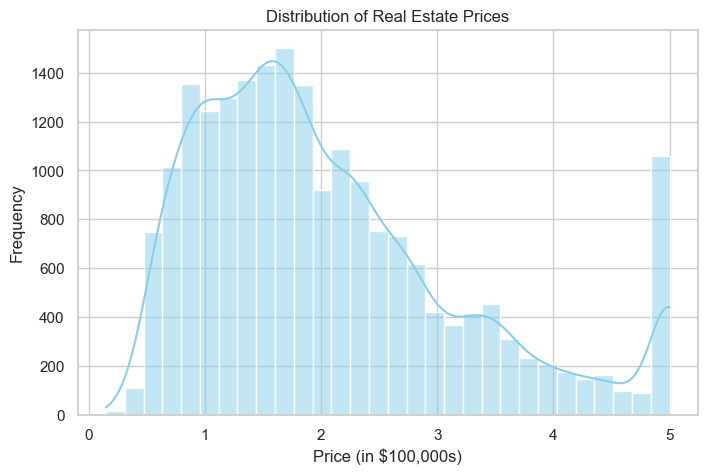

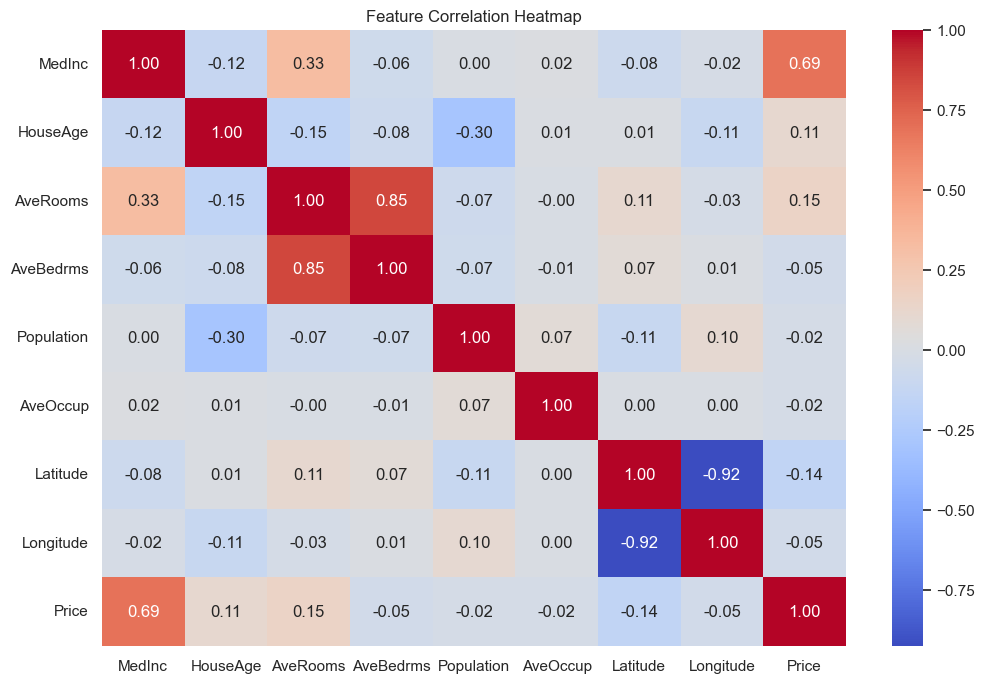

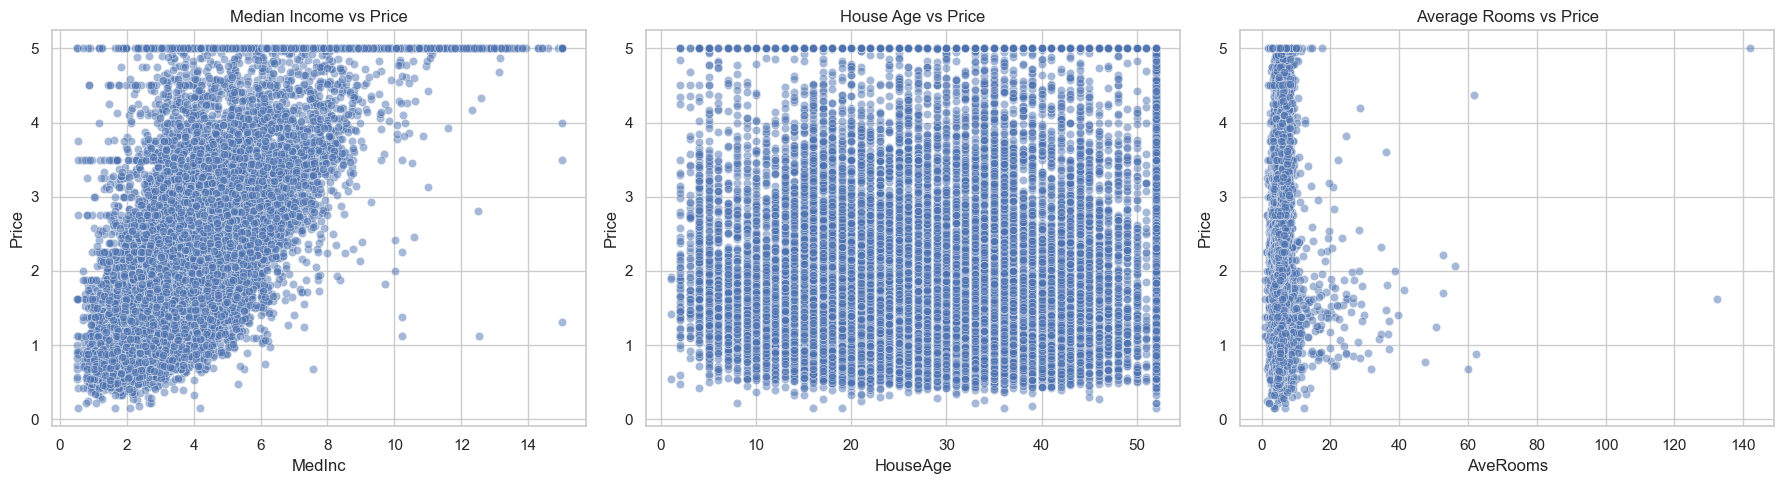

In [4]:
# 1. Distribution of the Target Variable (Price)
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Real Estate Prices')
plt.xlabel('Price (in $100,000s)')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Key Relationships with Price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MedInc vs Price
sns.scatterplot(x='MedInc', y='Price', data=df, alpha=0.5, ax=axes[0])
axes[0].set_title('Median Income vs Price')

# HouseAge vs Price
sns.scatterplot(x='HouseAge', y='Price', data=df, alpha=0.5, ax=axes[1])
axes[1].set_title('House Age vs Price')

# AveRooms vs Price
sns.scatterplot(x='AveRooms', y='Price', data=df, alpha=0.5, ax=axes[2])
axes[2].set_title('Average Rooms vs Price')

plt.tight_layout()
plt.show()

In [5]:
# Save the cleaned dataframe to a CSV file in the data folder
# This ensures our Streamlit app and model training script use the exact same data
df.to_csv('../data/housing_clean.csv', index=False)
print("Cleaned data saved to ../data/housing_clean.csv")

Cleaned data saved to ../data/housing_clean.csv
